# Validation Set Evaluation — Augmented Dataset
Runs demucs -> tab CRNN pipeline over clean synthetic MusDB18 + Guitarset mix dataset with randomized mixing parameters (reverb, mix bleeding, compression)
Used to determine benchmark of the pipeline on more realistic music track conditions (still relies on Guitarset since .jams annotation needed, unfortunately not representitve of real songs)

Dataset Dir:
`guitarset_demucs/guitarset_mixes_dataset_augmented/val/`.

In [13]:
import sys, os
from pathlib import Path

REPO_ROOT = Path(os.getcwd())
SRC_DIR   = REPO_ROOT / 'src'
for p in [str(REPO_ROOT), str(SRC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

In [14]:
import torch
import numpy as np
import jams
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config
from src.run_pipeline import PipelineState, Node, run_pipeline
from src.nodes import stem_extraction, load_model, predict
from evaluation.metrics import calculate_note_level_metrics, calculate_onset_event_metrics

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────────
VAL_DIR       = REPO_ROOT / 'guitarset_demucs' / 'guitarset_mixes_dataset_augmented' / 'val'
ARTIFACTS_DIR = REPO_ROOT / 'hyperparam_set_v1'
ONSET_THRESH  = config.DEFAULT_TDR_THRESHOLD   # 0.5

# Auto-detect device
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

# Open-string MIDI pitches: string 0 = low E (40), ..., string 5 = high e (64)
OPEN_STRING_PITCHES = config.OPEN_STRING_PITCHES_MIDI  # {0:40,1:45,2:50,3:55,4:59,5:64}

In [16]:
# ── Select model run ───────────────────────────────────────────────────────────
runs = sorted([d for d in ARTIFACTS_DIR.iterdir()
               if d.is_dir() and (d / 'best_model.pth').exists()])

print('Available runs:')
for i, r in enumerate(runs):
    print(f'  [{i}] {r.name}')

Available runs:
  [0] run_4_Baseline_run72_re-run_with_new_aug_augEnabled
  [1] run_5_Test_Higher_Dropout_0.55_augEnabled
  [2] run_6_Test_More_Patient_Scheduler_12_augEnabled
  [3] run_7_Test_Higher_OnsetLossWeight_10_augEnabled
  [4] run_8_Test_Higher_Dropout_and_Patient_Scheduler_augEnabled


In [17]:
RUN_IDX = 3   # ← change this to select a different run

run_dir = runs[RUN_IDX]
print(f'Loading: {run_dir.name}')

# Build a state just to load the model once — reused for all tracks
_init_state = PipelineState(
    input_path=Path('/dev/null'),
    artifacts_dir=ARTIFACTS_DIR,
    extras={'device': DEVICE, 'run_name': run_dir.name},
)
_init_state = load_model(_init_state)
shared_model = _init_state.model
print('Model loaded.')

Loading: run_7_Test_Higher_OnsetLossWeight_10_augEnabled
--- Próba załadowania modelu z pliku: best_model.pth ---
Odtworzone parametry inicjalizacyjne: {'num_frames_rnn_input_dim': 1280, 'rnn_type': 'GRU', 'rnn_hidden_size': 768, 'rnn_layers': 2, 'rnn_dropout': 0.5, 'rnn_bidirectional': True}
Ładowanie wag na urządzenie: mps
Model pomyślnie załadowany i przeniesiony na urządzenie: mps
Model loaded.


In [18]:
def parse_gt_notes_from_jams(jams_path):
    """Return list of GT note dicts from a GuitarSet JAMS file.
    Each annotation in note_midi corresponds to one string (index 0-5).
    obs.time and obs.duration are plain floats (seconds).
    """
    j = jams.load(str(jams_path))
    note_anns = j.search(namespace='note_midi')
    notes = []
    for string_idx, ann in enumerate(note_anns):
        open_pitch = OPEN_STRING_PITCHES[string_idx]
        for obs in ann.data:
            pitch = int(round(obs.value))
            fret  = pitch - open_pitch
            if 0 <= fret <= config.MAX_FRETS:
                notes.append({
                    'start_time': float(obs.time),
                    'end_time':   float(obs.time + obs.duration),
                    'pitch_midi': pitch,
                    'string':     string_idx,
                    'fret':       fret,
                })
    return notes

In [19]:
def gt_notes_to_raw_tensor(gt_notes):
    """Convert GT note list to the (N,4) tensor format expected by metrics.py."""
    if not gt_notes:
        return torch.zeros((0, 4))
    rows = [[n['start_time'], n['end_time'], n['string'], n['fret']] for n in gt_notes]
    return torch.tensor(rows, dtype=torch.float32)

In [20]:
# ── Run evaluation over all val tracks ────────────────────────────────────────
PIPELINE_NODES = [
    Node("stem_extraction", stem_extraction),
    Node("predict",         predict),
]

wav_files = sorted(VAL_DIR.glob('*.wav'))
print(f'Evaluating {len(wav_files)} tracks...')

results = []

for wav_path in tqdm(wav_files):
    track_id  = wav_path.stem
    jams_path = wav_path.with_suffix('.jams')

    if not jams_path.exists():
        print(f'  [SKIP] No JAMS for {track_id}')
        continue

    try:
        state = PipelineState(
            input_path=wav_path,
            artifacts_dir=ARTIFACTS_DIR,
            model=shared_model,   # reuse loaded model — no reload per track
            extras={'device': DEVICE, 'run_name': run_dir.name},
        )
        state = run_pipeline(state, PIPELINE_NODES)

        pred_notes = state.predicted_notes or []
        gt_notes   = parse_gt_notes_from_jams(jams_path)
        gt_raw     = gt_notes_to_raw_tensor(gt_notes)

        tdr   = calculate_note_level_metrics(pred_notes, gt_raw)
        onset = calculate_onset_event_metrics(pred_notes, gt_raw)

        results.append({
            'track':           track_id,
            'n_gt_notes':      len(gt_notes),
            'n_pred_notes':    len(pred_notes),
            'tdr_precision':   tdr['tdr_precision'],
            'tdr_recall':      tdr['tdr_recall'],
            'tdr_f1':          tdr['tdr_f1'],
            'onset_precision': onset['onset_precision_event'],
            'onset_recall':    onset['onset_recall_event'],
            'onset_f1':        onset['onset_f1_event'],
        })

    except Exception as e:
        print(f'  [ERROR] {track_id}: {e}')

df = pd.DataFrame(results)
print(f'\nDone. {len(df)} tracks evaluated.')

Evaluating 72 tracks...


  0%|          | 0/72 [00:00<?, ?it/s]

INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Loading model: htdemucs_6s


[RUN]  stem_extraction


INFO:stem_extraction:Separating stems for: 00_BN1-129-Eb_solo.wav
/Users/jonathanc/dev/Tablio/venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/Users/jonathanc/dev/Tablio/venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec

...

[RUN]  predict


INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Loading model: htdemucs_6s


[RUN]  stem_extraction


INFO:stem_extraction:Separating stems for: 05_SS3-98-C_solo.wav
INFO:stem_extraction:Stem saved to: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/05_SS3-98-C_solo.wav


[RUN]  predict

Done. 72 tracks evaluated.


In [21]:
# ── Summary statistics ─────────────────────────────────────────────────────────
metric_cols = ['tdr_precision','tdr_recall','tdr_f1','onset_precision','onset_recall','onset_f1']
summary = df[metric_cols].agg(['mean','median','std']).T
summary.columns = ['mean','median','std']
print(f'Run: {run_dir.name}\n')
print(summary.to_string(float_format='{:.3f}'.format))

Run: run_7_Test_Higher_OnsetLossWeight_10_augEnabled

                 mean  median   std
tdr_precision   0.883   0.917 0.103
tdr_recall      0.813   0.899 0.187
tdr_f1          0.837   0.889 0.157
onset_precision 0.931   0.956 0.084
onset_recall    0.683   0.725 0.247
onset_f1        0.762   0.811 0.193


In [22]:
# ── Per-track table ────────────────────────────────────────────────────────────
df.set_index('track')[metric_cols].sort_values('tdr_f1', ascending=False).style.format('{:.3f}').background_gradient(cmap='RdYlGn', axis=0)

,tdr_precision,tdr_recall,tdr_f1,onset_precision,onset_recall,onset_f1
track,,,,,,
05_Rock3-117-Bb_solo,0.959,1.000,0.979,0.958,1.000,0.979
02_Jazz2-110-Bb_solo,0.947,1.000,0.973,0.947,1.000,0.973
04_BN1-147-Gb_solo,1.000,0.935,0.967,1.000,0.855,0.922
02_Jazz1-200-B_solo,0.953,0.976,0.965,0.953,0.976,0.965
05_Jazz1-200-B_solo,0.979,0.940,0.959,0.979,0.940,0.959
01_SS1-100-C#_comp,0.932,0.987,0.958,0.967,0.477,0.639
01_BN1-129-Eb_comp,0.971,0.943,0.957,0.988,0.781,0.872
03_Jazz1-130-D_comp,0.966,0.944,0.955,0.976,0.444,0.611
03_Jazz1-200-B_solo,0.933,0.977,0.955,0.956,1.000,0.977


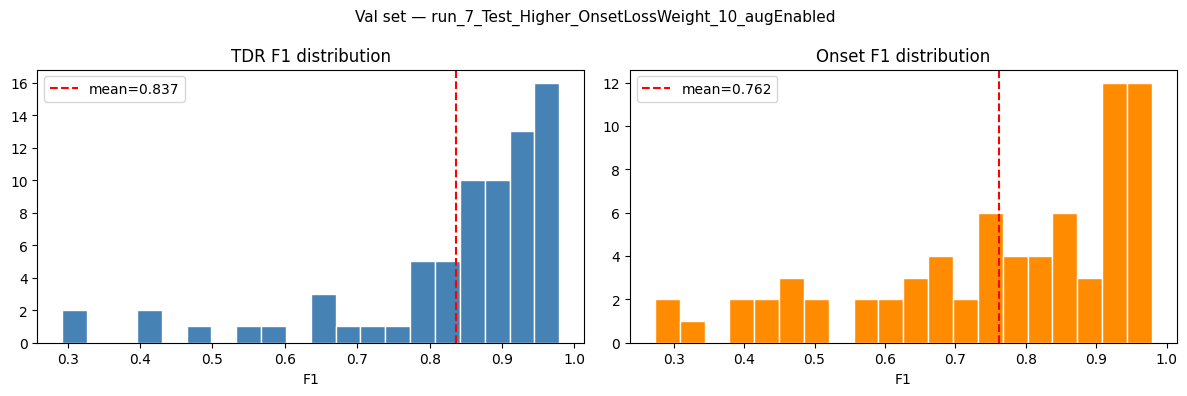

In [23]:
# ── Distribution plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Val set — {run_dir.name}', fontsize=11)

axes[0].hist(df['tdr_f1'],    bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df['tdr_f1'].mean(), color='red', linestyle='--', label=f'mean={df["tdr_f1"].mean():.3f}')
axes[0].set_title('TDR F1 distribution')
axes[0].set_xlabel('F1'); axes[0].legend()

axes[1].hist(df['onset_f1'], bins=20, color='darkorange', edgecolor='white')
axes[1].axvline(df['onset_f1'].mean(), color='red', linestyle='--', label=f'mean={df["onset_f1"].mean():.3f}')
axes[1].set_title('Onset F1 distribution')
axes[1].set_xlabel('F1'); axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# ── Best and worst tracks ──────────────────────────────────────────────────────
n = 5
print(f'Top {n} tracks (TDR F1):')
print(df.nlargest(n, 'tdr_f1')[['track','tdr_f1','onset_f1','n_gt_notes']].to_string(index=False))
print(f'\nBottom {n} tracks (TDR F1):')
print(df.nsmallest(n, 'tdr_f1')[['track','tdr_f1','onset_f1','n_gt_notes']].to_string(index=False))

Top 5 tracks (TDR F1):
               track   tdr_f1  onset_f1  n_gt_notes
05_Rock3-117-Bb_solo 0.979021  0.978723          70
02_Jazz2-110-Bb_solo 0.972973  0.972973          54
  04_BN1-147-Gb_solo 0.966667  0.921739          62
 02_Jazz1-200-B_solo 0.964706  0.964706          42
 05_Jazz1-200-B_solo 0.959184  0.959184          50

Bottom 5 tracks (TDR F1):
               track   tdr_f1  onset_f1  n_gt_notes
02_Funk3-112-C#_solo 0.292683  0.273292         139
02_Funk3-112-C#_comp 0.306452  0.288136         200
00_Funk1-114-Ab_solo 0.404762  0.404762          58
  05_Rock2-85-F_comp 0.422414  0.326034         325
05_Jazz2-110-Bb_comp 0.493359  0.426396         252
